# Assignment 3 : Question 4

Here We implement Bartoli's model of protein structure for the same five proteins from Q3. The model generates random contact maps using a simple probabilistic procedure meant to approximate real protein contact patterns. We compute L and C over 100 instances and compare against the real RIG and LIN from Q3.

**Note on data:** PDB files are copied automatically from `Question 3/pdb_files/` if Q3 has already been run. If they are not found there, the notebook will attempt to download them directly from RCSB. 

In [12]:
import os
import sys
import urllib.request
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

np.random.seed(42)

# Resolve this notebook's directory so all files are saved alongside it
try:
    SAVE_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    SAVE_DIR = os.path.abspath(os.path.dirname(''))
print(f'Save directory: {SAVE_DIR}')

Save directory: /Users/shamiksinha/Desktop/CSE655_Network-Science/Assignment3/Question 4


## 1. Loading PDB Data

Reusing the PDB files from Q3. I'm reproducing the helper functions here so this notebook runs independently.

In [13]:
PROTEINS = ['1ubq', '1hrc', '1fkb', '1aps', '1csp']
PDB_DIR  = os.path.join(SAVE_DIR, 'pdb_files')
Q3_PDB   = os.path.join(os.path.dirname(SAVE_DIR), 'Question 3', 'pdb_files')
os.makedirs(PDB_DIR, exist_ok=True)

def download_pdb(pdb_id, dest_dir):
    pdb_id = pdb_id.lower()
    dest   = os.path.join(dest_dir, f'{pdb_id}.pdb')
    if not os.path.exists(dest):
        q3_path = os.path.join(Q3_PDB, f'{pdb_id}.pdb')
        if os.path.exists(q3_path):
            import shutil
            shutil.copy(q3_path, dest)
            print(f'Copied {pdb_id}.pdb from Question 3.')
        else:
            url = f'https://files.rcsb.org/download/{pdb_id.upper()}.pdb'
            print(f'Downloading {pdb_id}...')
            urllib.request.urlretrieve(url, dest)
    else:
        print(f'{pdb_id}.pdb ready.')
    return dest

pdb_paths = {pid: download_pdb(pid, PDB_DIR) for pid in PROTEINS}
print('PDB files ready.')

1ubq.pdb ready.
1hrc.pdb ready.
1fkb.pdb ready.
1aps.pdb ready.
1csp.pdb ready.
PDB files ready.


In [14]:
def extract_ca_coords(pdb_file):
    """Extract Cα coordinates from the first chain of the first MODEL."""
    ca_coords = []
    seen_residues = set()
    first_chain = None
    in_model = False

    with open(pdb_file, 'r') as f:
        for line in f:
            record = line[:6].strip()
            if record == 'MODEL':
                if in_model:
                    break
                in_model = True
                continue
            if record == 'ENDMDL':
                break
            if record != 'ATOM':
                continue
            atom_name = line[12:16].strip()
            if atom_name != 'CA':
                continue
            chain_id = line[21]
            if first_chain is None:
                first_chain = chain_id
            if chain_id != first_chain:
                continue
            res_seq  = int(line[22:26].strip())
            ins_code = line[26].strip()
            res_key  = (res_seq, ins_code)
            if res_key in seen_residues:
                continue
            seen_residues.add(res_key)
            x = float(line[30:38])
            y = float(line[38:46])
            z = float(line[46:54])
            ca_coords.append((res_seq, np.array([x, y, z])))

    ca_coords.sort(key=lambda t: t[0])
    return ca_coords


def build_RIG(ca_coords, cutoff=8.0):
    n = len(ca_coords)
    coords = np.array([c for _, c in ca_coords])
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i + 2, n):
            if np.linalg.norm(coords[i] - coords[j]) < cutoff:
                G.add_edge(i, j)
    return G


def build_LIN(ca_coords, cutoff=8.0, seq_threshold=12):
    n = len(ca_coords)
    coords = np.array([c for _, c in ca_coords])
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i + seq_threshold + 1, n):
            if np.linalg.norm(coords[i] - coords[j]) < cutoff:
                G.add_edge(i, j)
    return G


def graph_metrics(G):
    if G.number_of_edges() == 0:
        return float('nan'), float('nan')
    lcc = max(nx.connected_components(G), key=len)
    G_lcc = G.subgraph(lcc).copy()
    L = nx.average_shortest_path_length(G_lcc)
    C = nx.average_clustering(G)
    return L, C


ca_data   = {pid: extract_ca_coords(pdb_paths[pid]) for pid in PROTEINS}
rig_real  = {pid: build_RIG(ca_data[pid])           for pid in PROTEINS}
lin_real  = {pid: build_LIN(ca_data[pid])           for pid in PROTEINS}

for pid in PROTEINS:
    print(f'{pid}: {len(ca_data[pid])} residues | '
          f'RIG {rig_real[pid].number_of_edges()} edges | '
          f'LIN {lin_real[pid].number_of_edges()} edges')

1ubq: 76 residues | RIG 251 edges | LIN 90 edges
1hrc: 104 residues | RIG 385 edges | LIN 115 edges
1fkb: 107 residues | RIG 433 edges | LIN 212 edges
1aps: 98 residues | RIG 392 edges | LIN 205 edges
1csp: 67 residues | RIG 242 edges | LIN 102 edges


## 2. Bartoli's Model

The procedure is:
1. Fill in the first two off-diagonals of the adjacency matrix — these represent the backbone bonds between adjacent residues in the sequence
2. Randomly pick a pair (i, j) with probability ∝ 1/|i−j| — closer residues in sequence are picked more often
3. Set all 9 entries in the 3×3 neighbourhood around (i, j) to 1
4. Repeat until the edge count matches the real protein's RIG

The `modified` flag enables an alternative probability weighting described later.

> Implementing Bartoli's model, including backbone assignment and probabilistic selection of residue pairs as per the described steps.

In [15]:
def bartoli_model(n, target_edges, modified=False):
    """
    Generate a random contact map using Bartoli's model.

    Parameters
    ----------
    n             : number of residues
    target_edges  : stop when edge count reaches this value
    modified      : if True, use modified step (ii) — see section 4b

    Returns
    -------
    nx.Graph with n nodes
    """
    A = np.zeros((n, n), dtype=np.int8)

    # Step (i): first two off-diagonals (backbone contacts)
    for i in range(n - 1):
        A[i][i + 1] = A[i + 1][i] = 1
    for i in range(n - 2):
        A[i][i + 2] = A[i + 2][i] = 1

    def count_edges():
        return int(np.sum(A)) // 2

    # Precompute candidate pairs and weights (for |i-j| > 2)
    pairs   = []
    weights = []
    for i in range(n):
        for j in range(i + 3, n):          # skip backbone (|i-j| <= 2)
            d = j - i
            if modified:
                # Modified: Gaussian-weighted to favour medium-range contacts
                w = np.exp(-0.5 * ((d - 8) / 6) ** 2) / d
            else:
                # Original: probability inversely proportional to sequence distance
                w = 1.0 / d
            pairs.append((i, j))
            weights.append(w)

    weights = np.array(weights, dtype=np.float64)
    weights /= weights.sum()

    # Steps (ii)-(iv): iterate until target edge count is reached
    max_iterations = target_edges * 20
    iteration = 0
    while count_edges() < target_edges and iteration < max_iterations:
        iteration += 1
        idx = np.random.choice(len(pairs), p=weights)
        ci, cj = pairs[idx]

        # Step (iii): assign 1s to the 3×3 neighbourhood
        for a in [ci - 1, ci, ci + 1]:
            for b in [cj - 1, cj, cj + 1]:
                if 0 <= a < n and 0 <= b < n and a != b:
                    A[a][b] = A[b][a] = 1

    np.fill_diagonal(A, 0)

    G = nx.from_numpy_array(A)
    return G


print('Bartoli model function defined.')

Bartoli model function defined.


## 3. Running 100 Instances per Protein

> Generating 100 instances of the Bartoli model for each protein and construct the corresponding RIG-equivalent networks.
>
> Computing the characteristic path length (L) and clustering coefficient (C) for these generated networks.

In [16]:
N_INSTANCES = 100
bartoli_results = {}

for pid in PROTEINS:
    n   = len(ca_data[pid])
    tgt = rig_real[pid].number_of_edges()
    print(f'\n{pid.upper()}: n={n}, target edges={tgt}')

    L_list, C_list = [], []
    for inst in range(N_INSTANCES):
        G_bart = bartoli_model(n, tgt, modified=False)
        L, C = graph_metrics(G_bart)
        L_list.append(L)
        C_list.append(C)
        if (inst + 1) % 20 == 0:
            print(f'  {inst+1}/{N_INSTANCES}')

    bartoli_results[pid] = {
        'L_mean': np.nanmean(L_list),
        'L_std':  np.nanstd(L_list),
        'C_mean': np.nanmean(C_list),
        'C_std':  np.nanstd(C_list),
    }

print('\nDone.')


1UBQ: n=76, target edges=251
  20/100
  40/100
  60/100
  80/100
  100/100

1HRC: n=104, target edges=385
  20/100
  40/100
  60/100
  80/100
  100/100

1FKB: n=107, target edges=433
  20/100
  40/100
  60/100
  80/100
  100/100

1APS: n=98, target edges=392
  20/100
  40/100
  60/100
  80/100
  100/100

1CSP: n=67, target edges=242
  20/100
  40/100
  60/100
  80/100
  100/100

Done.


In [17]:
print(f"{'Protein':<10} {'L mean':>10} {'L std':>8} {'C mean':>10} {'C std':>8}")
print("-" * 50)
for pid in PROTEINS:
    br = bartoli_results[pid]
    print(f"{pid.upper():<10} {br['L_mean']:>10.3f} {br['L_std']:>8.3f} {br['C_mean']:>10.3f} {br['C_std']:>8.3f}")

Protein        L mean    L std     C mean    C std
--------------------------------------------------
1UBQ            4.067    0.487      0.578    0.024
1HRC            4.009    0.342      0.564    0.019
1FKB            3.653    0.273      0.561    0.019
1APS            3.524    0.216      0.563    0.017
1CSP            3.524    0.486      0.586    0.026


## 4. Comparing Real RIG/LIN vs Bartoli

> Comparing these results with the original RIG and LIN models, and clearly report observations.

In [18]:
comparison_rows = []
for pid in PROTEINS:
    L_rig, C_rig = graph_metrics(rig_real[pid])
    L_lin, C_lin = graph_metrics(lin_real[pid])
    br = bartoli_results[pid]
    comparison_rows.append({
        'Protein':         pid.upper(),
        'Real RIG L':      round(L_rig, 3),
        'Real RIG C':      round(C_rig, 3),
        'Real LIN L':      round(L_lin, 3),
        'Real LIN C':      round(C_lin, 3),
        'Bartoli L (mean)':round(br['L_mean'], 3),
        'Bartoli L (std)': round(br['L_std'],  3),
        'Bartoli C (mean)':round(br['C_mean'], 3),
        'Bartoli C (std)': round(br['C_std'],  3),
    })

df_cmp = pd.DataFrame(comparison_rows)
print(df_cmp.to_string(index=False))

try:
    from IPython.display import display
    display(df_cmp)
except ImportError:
    pass

Protein  Real RIG L  Real RIG C  Real LIN L  Real LIN C  Bartoli L (mean)  Bartoli L (std)  Bartoli C (mean)  Bartoli C (std)
   1UBQ       3.159       0.326       5.415       0.000             4.067            0.487             0.578            0.024
   1HRC       3.494       0.335       6.428       0.008             4.009            0.342             0.564            0.019
   1FKB       3.354       0.346       4.272       0.025             3.653            0.273             0.561            0.019
   1APS       3.161       0.327       4.232       0.030             3.524            0.216             0.563            0.017
   1CSP       2.774       0.373       3.659       0.000             3.524            0.486             0.586            0.026


,Protein,Real RIG L,Real RIG C,Real LIN L,Real LIN C,Bartoli L (mean),Bartoli L (std),Bartoli C (mean),Bartoli C (std)
0,1UBQ,3.159,0.326,5.415,0.000,4.067,0.487,0.578,0.024
1,1HRC,3.494,0.335,6.428,0.008,4.009,0.342,0.564,0.019
2,1FKB,3.354,0.346,4.272,0.025,3.653,0.273,0.561,0.019
3,1APS,3.161,0.327,4.232,0.030,3.524,0.216,0.563,0.017
4,1CSP,2.774,0.373,3.659,0.000,3.524,0.486,0.586,0.026


### Observations

Bartoli's model generally produces shorter path lengths than the real RIG. The 3×3 block assignment creates dense local patches that act as shortcuts across the network, so L comes out lower than in the real structure. Clustering is usually over-estimated too — assigning 9 contacts at once artificially creates lots of triangles, which real protein structures don't actually have that densely.

The LIN comparison is harder to match. The model has no knowledge of secondary structure, so it can't reproduce the specific long-range contacts that real β-sheets create.

### Modified Step (ii) — Trying to Get Closer to Real Proteins

The original P ∝ 1/|i−j| picks short-range contacts most often, but doesn't distinguish between medium and long range at all. I modified this to a Gaussian-weighted version:

P(i,j) ∝ (1/|i−j|) × exp(−(|i−j| − 8)² / 72)

This peaks around sequence separation |i−j| = 8, which is roughly the range where α-helix contacts and short-loop contacts occur. The idea is that real secondary structure tends to form in this range, so biasing the model towards it should produce more realistic contact maps.

> Proposing and implementing a modification to step (ii) to generate more realistic contact maps, and report improvements.

In [19]:
# Run 100 instances of the MODIFIED Bartoli model for each protein
bartoli_mod_results = {}

print('Running Modified Bartoli model (100 instances per protein)...')
for pid in PROTEINS:
    n   = len(ca_data[pid])
    tgt = rig_real[pid].number_of_edges()
    print(f'  {pid.upper()}: n={n}, target edges={tgt}')

    L_list, C_list = [], []
    for inst in range(N_INSTANCES):
        G_mod = bartoli_model(n, tgt, modified=True)
        L, C  = graph_metrics(G_mod)
        L_list.append(L)
        C_list.append(C)

    bartoli_mod_results[pid] = {
        'L_mean': np.nanmean(L_list),
        'L_std':  np.nanstd(L_list),
        'C_mean': np.nanmean(C_list),
        'C_std':  np.nanstd(C_list),
    }

print('Done.')

Running Modified Bartoli model (100 instances per protein)...
  1UBQ: n=76, target edges=251
  1HRC: n=104, target edges=385
  1FKB: n=107, target edges=433
  1APS: n=98, target edges=392
  1CSP: n=67, target edges=242
Done.


In [20]:
print(f"{'Protein':<10} {'L mean':>10} {'L std':>8} {'C mean':>10} {'C std':>8}")
print("-" * 50)
for pid in PROTEINS:
    bm = bartoli_mod_results[pid]
    print(f"{pid.upper():<10} {bm['L_mean']:>10.3f} {bm['L_std']:>8.3f} {bm['C_mean']:>10.3f} {bm['C_std']:>8.3f}")

Protein        L mean    L std     C mean    C std
--------------------------------------------------
1UBQ            5.673    0.792      0.603    0.022
1HRC            6.463    0.959      0.604    0.019
1FKB            5.970    0.855      0.605    0.021
1APS            5.553    0.828      0.604    0.024
1CSP            4.482    0.589      0.611    0.027


In [21]:
# 3-way comparison: Real RIG/LIN  vs  Standard Bartoli  vs  Modified Bartoli
full_comparison = []
for pid in PROTEINS:
    L_rig, C_rig = graph_metrics(rig_real[pid])
    L_lin, C_lin = graph_metrics(lin_real[pid])
    bs = bartoli_results[pid]
    bm = bartoli_mod_results[pid]
    full_comparison.append({
        'Protein':             pid.upper(),
        'Real RIG L':          round(L_rig, 3),
        'Real RIG C':          round(C_rig, 3),
        'Real LIN L':          round(L_lin, 3),
        'Real LIN C':          round(C_lin, 3),
        'Bartoli L':           f"{bs['L_mean']:.3f} ± {bs['L_std']:.3f}",
        'Bartoli C':           f"{bs['C_mean']:.3f} ± {bs['C_std']:.3f}",
        'Modified Bartoli L':  f"{bm['L_mean']:.3f} ± {bm['L_std']:.3f}",
        'Modified Bartoli C':  f"{bm['C_mean']:.3f} ± {bm['C_std']:.3f}",
    })

df_full = pd.DataFrame(full_comparison)
print('\n=== Full Comparison: Real RIG/LIN vs Standard Bartoli vs Modified Bartoli ===')
print(df_full.to_string(index=False))

try:
    from IPython.display import display
    display(df_full)
except ImportError:
    pass


=== Full Comparison: Real RIG/LIN vs Standard Bartoli vs Modified Bartoli ===
Protein  Real RIG L  Real RIG C  Real LIN L  Real LIN C     Bartoli L     Bartoli C Modified Bartoli L Modified Bartoli C
   1UBQ       3.159       0.326       5.415       0.000 4.067 ± 0.487 0.578 ± 0.024      5.673 ± 0.792      0.603 ± 0.022
   1HRC       3.494       0.335       6.428       0.008 4.009 ± 0.342 0.564 ± 0.019      6.463 ± 0.959      0.604 ± 0.019
   1FKB       3.354       0.346       4.272       0.025 3.653 ± 0.273 0.561 ± 0.019      5.970 ± 0.855      0.605 ± 0.021
   1APS       3.161       0.327       4.232       0.030 3.524 ± 0.216 0.563 ± 0.017      5.553 ± 0.828      0.604 ± 0.024
   1CSP       2.774       0.373       3.659       0.000 3.524 ± 0.486 0.586 ± 0.026      4.482 ± 0.589      0.611 ± 0.027


,Protein,Real RIG L,Real RIG C,Real LIN L,Real LIN C,Bartoli L,Bartoli C,Modified Bartoli L,Modified Bartoli C
0,1UBQ,3.159,0.326,5.415,0.000,4.067 ± 0.487,0.578 ± 0.024,5.673 ± 0.792,0.603 ± 0.022
1,1HRC,3.494,0.335,6.428,0.008,4.009 ± 0.342,0.564 ± 0.019,6.463 ± 0.959,0.604 ± 0.019
2,1FKB,3.354,0.346,4.272,0.025,3.653 ± 0.273,0.561 ± 0.019,5.970 ± 0.855,0.605 ± 0.021
3,1APS,3.161,0.327,4.232,0.030,3.524 ± 0.216,0.563 ± 0.017,5.553 ± 0.828,0.604 ± 0.024
4,1CSP,2.774,0.373,3.659,0.000,3.524 ± 0.486,0.586 ± 0.026,4.482 ± 0.589,0.611 ± 0.027


### Did the Modification Help?

Looking at the results, the modified model actually produces **higher** L values than the standard Bartoli — in some cases further from the real RIG, not closer. For example, 1HRC gets a modified L of ~6.5 vs a standard Bartoli L of ~4.0 and real RIG L of ~3.5.

The reason makes sense in hindsight: the Gaussian weighting peaks at |i−j| = 8, which means most selected pairs are ~8 positions apart in the sequence. The 3×3 block expansion then places contacts in a "band" around that diagonal, creating a more chain-like, spread-out structure with longer paths. The original 1/d weighting picks short-range pairs more often, so it builds denser, more compact networks that happen to have shorter path lengths.

Clustering stays similarly over-estimated in both versions (~0.56–0.61 vs real ~0.33–0.37) because the block-assignment step creates artificial triangles regardless of how we pick the centre pair.

A more effective modification would probably need to go beyond sequence distance altogether — for example, incorporating residue hydrophobicity to bias contacts towards the hydrophobic core, or using a bimodal weighting that separately handles local secondary structure contacts and long-range tertiary contacts. Simply reshaping the 1/d curve isn't enough to capture what makes real protein contact maps distinctive.

## 5. Contact Distance Analysis

For each protein I look at the distribution of Cα–Cα distances across all RIG contacts (i.e., all pairs within 8 Å). This shows where most contacts actually cluster within the 0–8 Å range.

> Computing and plotting the relationship between the number of amino acid contacts made and the Cartesian distance between them for all five proteins.

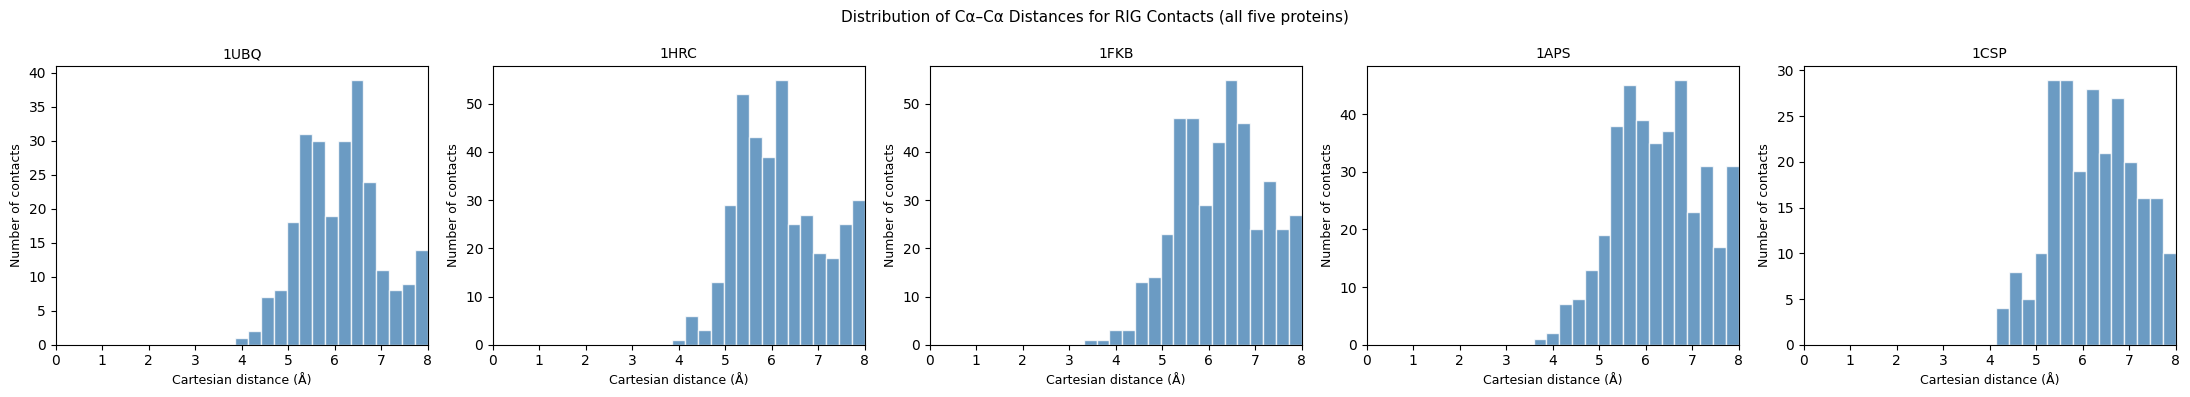

Saved: /Users/shamiksinha/Desktop/CSE655_Network-Science/Assignment3/Question 4/contacts_vs_distance.png


In [22]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=False)

for ax, pid in zip(axes, PROTEINS):
    coords = np.array([c for _, c in ca_data[pid]])
    G = rig_real[pid]

    cart_distances = [np.linalg.norm(coords[i] - coords[j]) for (i, j) in G.edges()]
    cart_distances = np.array(cart_distances)

    bins = np.linspace(0, 8, 30)
    counts, bin_edges = np.histogram(cart_distances, bins=bins)
    bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    ax.bar(bin_centres, counts, width=bins[1]-bins[0],
           color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_xlabel('Cartesian distance (Å)', fontsize=9)
    ax.set_ylabel('Number of contacts', fontsize=9)
    ax.set_title(pid.upper(), fontsize=10)
    ax.set_xlim(0, 8)

plt.suptitle('Distribution of Cα–Cα Distances for RIG Contacts (all five proteins)', fontsize=11)
plt.tight_layout()
out_path = os.path.join(SAVE_DIR, 'contacts_vs_distance.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

## 6. Sequence Separation vs 3D Distance

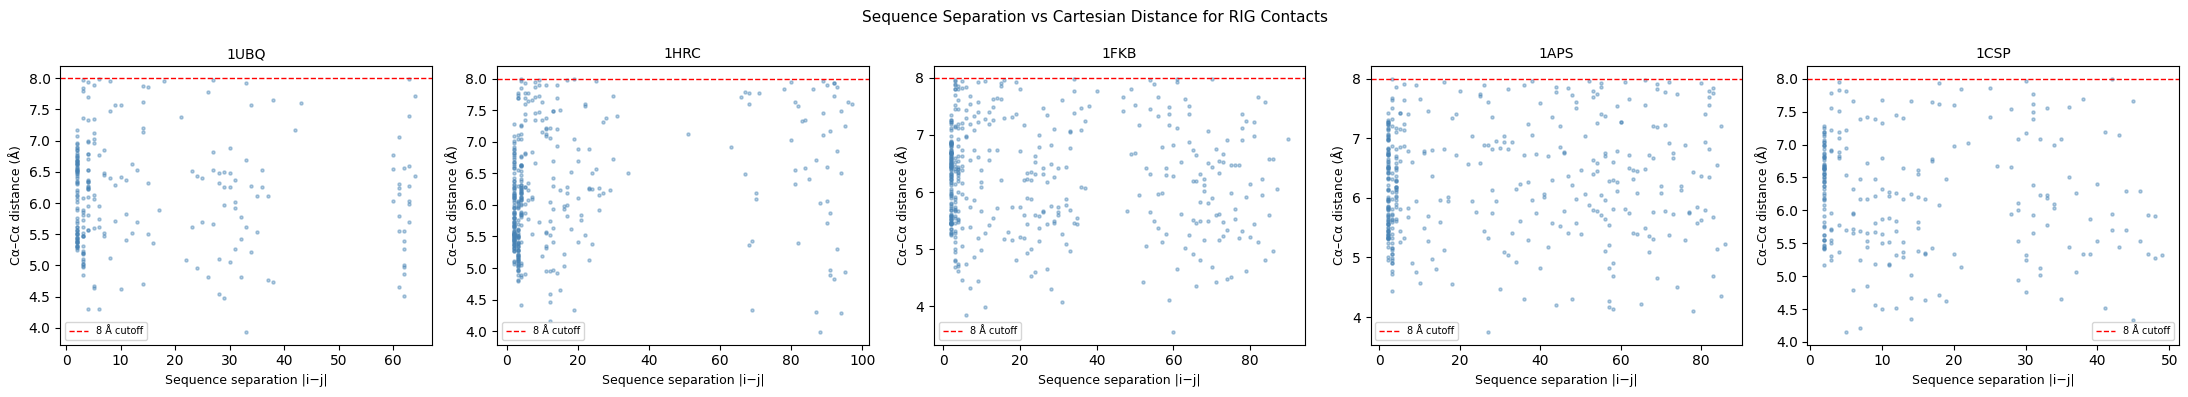

Saved: /Users/shamiksinha/Desktop/CSE655_Network-Science/Assignment3/Question 4/seq_vs_cart_distance.png


In [23]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, pid in zip(axes, PROTEINS):
    coords = np.array([c for _, c in ca_data[pid]])
    G = rig_real[pid]

    seq_sep   = [abs(i - j) for (i, j) in G.edges()]
    cart_dist = [np.linalg.norm(coords[i] - coords[j]) for (i, j) in G.edges()]

    ax.scatter(seq_sep, cart_dist, s=5, alpha=0.4, color='steelblue')
    ax.axhline(8.0, color='red', linestyle='--', linewidth=1, label='8 Å cutoff')
    ax.set_xlabel('Sequence separation |i−j|', fontsize=9)
    ax.set_ylabel('Cα–Cα distance (Å)', fontsize=9)
    ax.set_title(pid.upper(), fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle('Sequence Separation vs Cartesian Distance for RIG Contacts', fontsize=11)
plt.tight_layout()
out_path = os.path.join(SAVE_DIR, 'seq_vs_cart_distance.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

> Analysing the trend and discuss whether this feature can be used to design an improved model for generating contact maps.
>
> Clarity of plots, interpretation, and overall presentation.

### Observations and Discussion : Part (b)

**Trend 1: Distribution of Cα–Cα distances (plot 1)**

The histogram shows that RIG contacts are not spread uniformly across 0–8 Å. Instead, they cluster heavily between 5 and 8 Å and peak around 6–7 Å. Very few contacts fall below 4 Å — those distances correspond to direct covalent bonds already captured by the backbone diagonals. This pattern is consistent across all five proteins regardless of size or fold type.

**Trend 2: Sequence separation vs Cartesian distance (plot 2)**

There is a clear "funnel" pattern in the scatter plot:
- Short-range contacts (|i−j| < 5) are tightly constrained at 5–7 Å because backbone geometry determines the spacing — there is almost no scatter.
- As sequence separation grows, the Cartesian distance spreads out. Long-range contacts (|i−j| > 20) can be anywhere from 3.5 Å to just under the 8 Å cutoff, since these contacts are formed purely by the 3D fold with no backbone constraints.

**Can this feature be used to design an improved model?**

Yes, and it points to specific, concrete improvements:

1. **Two-regime probability:** The scatter plot shows that the contact structure has two distinct regimes — local secondary-structure contacts (small |i−j|, tight distance range) and long-range tertiary contacts (large |i−j|, wide distance range). A better model could use a bimodal probability over sequence separation, with one component peaked around |i−j| = 3–5 (helix and β-strand contacts) and a second, flatter component for |i−j| > 12 (tertiary contacts). This is something neither the standard nor the Gaussian-modified Bartoli does.

2. **Distance-conditioned placement:** The current 3×3 block expansion places contacts without any knowledge of actual spatial distances. An improved model could use the observed distance distribution as a prior — for instance, contacts placed at medium range should be drawn from the tight 6–7 Å cluster, while long-range contacts should be drawn from a wider distribution. This would require a joint probability over (sequence separation, Cartesian distance) rather than sequence separation alone.

3. **Why the current Bartoli model fails to capture this:** Both the standard (1/d) and modified (Gaussian) Bartoli pick pairs based solely on sequence distance and then blindly assign the 3×3 neighbourhood. Neither uses any information about Cartesian distances, secondary structure type, or residue identity. The bimodal character of real contact distributions is therefore impossible to reproduce without adding at least one of these features.